<a href="https://colab.research.google.com/github/mbenedicto99/Python4DataScience/blob/master/BENE_pinn_poisson2d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Trabalho 4 - Fazer a implementação de uma PINN

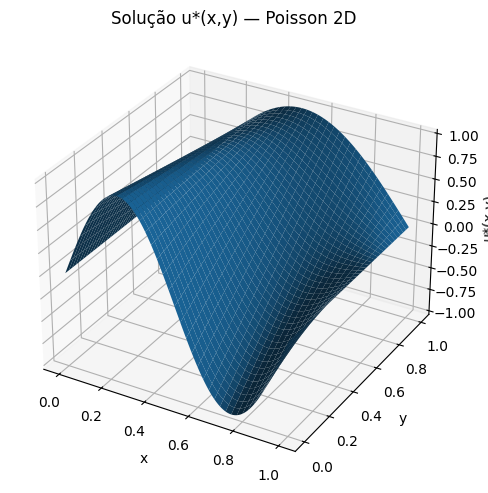

In [4]:
import numpy as np
import torch
import torch.nn as nn
from scipy.stats import qmc
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def init_xavier_tanh(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight, gain=nn.init.calculate_gain('tanh'))
        nn.init.zeros_(m.bias)


class MLP(nn.Module):
    def __init__(self, sizes=(2, 64, 64, 64, 1)):
        super().__init__()
        layers = []
        for i in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            if i < len(sizes) - 2:
                layers.append(nn.Tanh())
        self.net = nn.Sequential(*layers)
        self.apply(init_xavier_tanh)

    def forward(self, x):
        return self.net(x)


def u_star(xy: torch.Tensor) -> torch.Tensor:
    """Solução manufaturada: u*(x,y) = (1 - y) sin(2πx) + y sin(πx)."""
    x = xy[:, :1]
    y = xy[:, 1:2]
    return (1.0 - y) * torch.sin(2.0 * torch.pi * x) + y * torch.sin(torch.pi * x)


def f_source(xy: torch.Tensor) -> torch.Tensor:
    """f(x,y) = u_xx + u_yy para a u* acima."""
    x = xy[:, :1]
    y = xy[:, 1:2]
    return (-4.0 * (torch.pi ** 2) * torch.sin(2.0 * torch.pi * x) * (1.0 - y)
            - (torch.pi ** 2) * torch.sin(torch.pi * x) * y)


def poisson_residual(model: nn.Module, xy: torch.Tensor) -> torch.Tensor:
    """Resíduo r = u_xx + u_yy - f(x,y)."""
    xy = xy.detach().clone().requires_grad_(True)
    u = model(xy)

    du = torch.autograd.grad(u, xy, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = du[:, :1]
    u_y = du[:, 1:2]

    dux = torch.autograd.grad(u_x, xy, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    duy = torch.autograd.grad(u_y, xy, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]
    u_xx = dux[:, :1]
    u_yy = duy[:, 1:2]

    return u_xx + u_yy - f_source(xy)


def boundary_points(n_bc: int, device, dtype):
    """Gera pontos de contorno conforme o enunciado e seus valores u."""
    base = [n_bc // 4] * 4
    for i in range(n_bc - sum(base)):
        base[i % 4] += 1
    n_y0, n_y1, n_x0, n_x1 = base

    rng = np.random.default_rng(1)
    x1 = rng.random((n_y0, 1)); y1 = np.zeros((n_y0, 1)); u1 = np.sin(2 * np.pi * x1)
    x2 = rng.random((n_y1, 1)); y2 = np.ones((n_y1, 1));  u2 = np.sin(np.pi * x2)
    y3 = rng.random((n_x0, 1)); x3 = np.zeros((n_x0, 1)); u3 = np.zeros((n_x0, 1))
    y4 = rng.random((n_x1, 1)); x4 = np.ones((n_x1, 1));  u4 = np.zeros((n_x1, 1))

    X = np.vstack([
        np.hstack([x1, y1]),
        np.hstack([x2, y2]),
        np.hstack([x3, y3]),
        np.hstack([x4, y4]),
    ]).astype(np.float64)
    U = np.vstack([u1, u2, u3, u4]).astype(np.float64)

    return torch.as_tensor(X, dtype=dtype, device=device), torch.as_tensor(U, dtype=dtype, device=device)


def interior_points(n_f: int, device, dtype, method="sobol", eps=1e-6):
    """Pontos (x,y) no interior (0,1)x(0,1) para o termo da PDE."""
    if method == "sobol":
        eng = qmc.Sobol(d=2, scramble=True, seed=2)
        U = eng.random(n_f)
    elif method == "lhs":
        eng = qmc.LatinHypercube(d=2, seed=2)
        U = eng.random(n_f)
    else:
        rng = np.random.default_rng(2)
        U = rng.random((n_f, 2))
    U = U * (1 - 2 * eps) + eps
    return torch.as_tensor(U, dtype=dtype, device=device)


def relative_l2(u_pred: torch.Tensor, u_true: torch.Tensor) -> float:
    num = torch.linalg.norm(u_pred - u_true)
    den = torch.linalg.norm(u_true) + 1e-12
    return (num / den).item()

if __name__ == "__main__":
    # CPU + float64 para estabilidade numérica ou se quiser usar GPU/float32
    device = torch.device("cpu")
    dtype = torch.float64

    nx, ny = 121, 121
    x = torch.linspace(0, 1, nx, dtype=dtype, device=device)
    y = torch.linspace(0, 1, ny, dtype=dtype, device=device)
    Xg, Yg = torch.meshgrid(x, y, indexing="ij")

    XY = torch.stack([Xg.reshape(-1), Yg.reshape(-1)], dim=1)
    U = u_star(XY).reshape(nx, ny).cpu().numpy()
    Xn = Xg.cpu().numpy()
    Yn = Yg.cpu().numpy()

    # Gráfico
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(Xn, Yn, U)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("u*(x,y)")
    ax.set_title("Solução u*(x,y) — Poisson 2D")
    plt.tight_layout()